# 🤖 ESG Classification Modeling
**Objective:** Predict ESG performance category (Excellent, Good, Average, Poor) from environmental metrics.

**Features Used:** CarbonEmissions, WaterUsage, EnergyConsumption

**Models:** Logistic Regression, Random Forest, Gradient Boosting, SVM, KNN

---

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
 accuracy_score, precision_score, recall_score, f1_score,
 classification_report, confusion_matrix, roc_auc_score,
 ConfusionMatrixDisplay
)

import joblib
import os

## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('data/esg_processed.csv', index_col=0)
df.head()

,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption,ESG_Category
CompanyID,,,,,,,,,,,,,,,,
1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7,Good
1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4,Good
1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9,Good
1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2,Good
1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8,Good


In [4]:
df.dtypes

CompanyName           object
Industry              object
Region                object
Year                   int64
Revenue              float64
ProfitMargin         float64
MarketCap            float64
GrowthRate           float64
ESG_Overall          float64
ESG_Environmental    float64
ESG_Social           float64
ESG_Governance       float64
CarbonEmissions      float64
WaterUsage           float64
EnergyConsumption    float64
ESG_Category          object
dtype: object

In [6]:
df.isnull().sum()

CompanyName             0
Industry                0
Region                  0
Year                    0
Revenue                 0
ProfitMargin            0
MarketCap               0
GrowthRate           1000
ESG_Overall             0
ESG_Environmental       0
ESG_Social              0
ESG_Governance          0
CarbonEmissions         0
WaterUsage              0
EnergyConsumption       0
ESG_Category            0
dtype: int64

## 3. Preprocessing & Feature Engineering

In [9]:
fig = px.histogram(
 df, x='ESG_Category',
 color='ESG_Category',
 category_orders={'ESG_Category': ['Excellent', 'Good', 'Average', 'Poor']},
 title='ESG Category Distribution',
 color_discrete_map={
 'Excellent': '#2ecc71', 'Good': '#3498db',
 'Average': '#f39c12', 'Poor': '#e74c3c'
 }
)
fig.show()

In [10]:
FEATURES = ['CarbonEmissions', 'WaterUsage', 'EnergyConsumption']
TARGET = 'ESG_Category'

# Drop rows with missing values in selected columns
df_model = df[FEATURES + [TARGET]].dropna()
print(f'Modeling dataset shape: {df_model.shape}')

X = df_model[FEATURES]
y = df_model[TARGET]

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Classes: {le.classes_}')

Modeling dataset shape: (11000, 4)
Classes: ['Average' 'Excellent' 'Good' 'Poor']


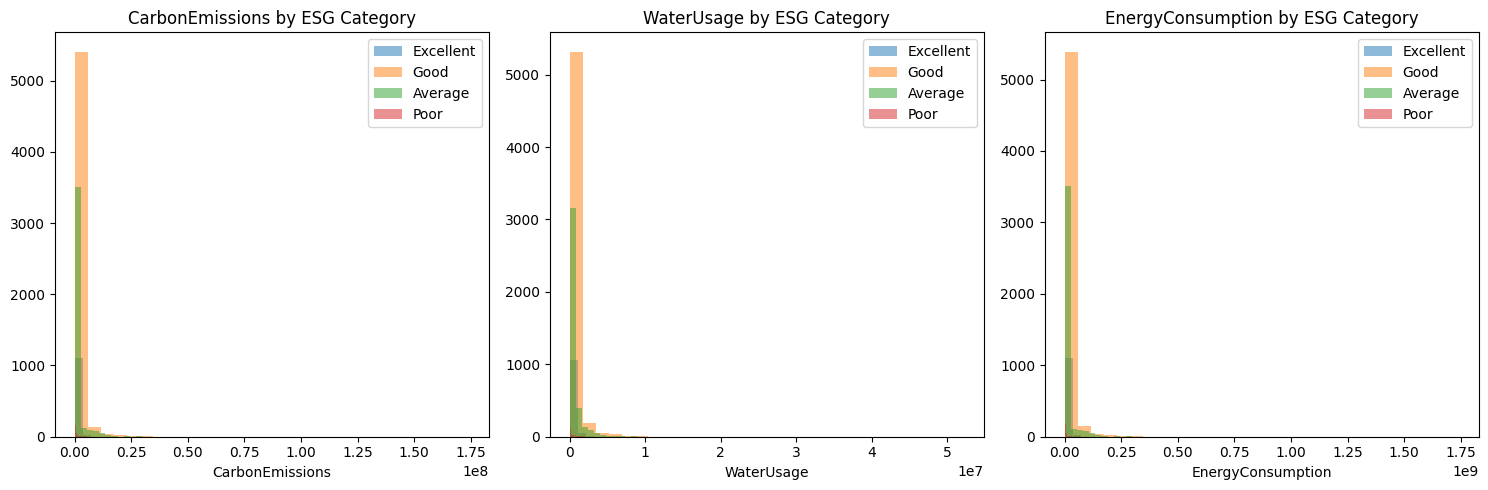

In [12]:
# Visualize feature distributions by ESG category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feature in enumerate(FEATURES):
 for category in ['Excellent', 'Good', 'Average', 'Poor']:
  subset = df_model[df_model[TARGET] == category][feature]
  axes[i].hist(subset, alpha=0.5, label=category, bins=30)
  axes[i].set_title(f'{feature} by ESG Category')
  axes[i].set_xlabel(feature)
  axes[i].legend()
plt.tight_layout()
plt.show()

## 4. Train-Test Split & Feature Scaling

In [13]:
# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
 X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train_scaled.shape}')
print(f'Test set: {X_test_scaled.shape}')

Training set: (8800, 3)
Test set: (2200, 3)


## 5. Model Training & Comparison

In [14]:
# Define all models
models = {
 'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
 'SVM': SVC(kernel='rbf', probability=True, random_state=42),
 'KNN': KNeighborsClassifier(n_neighbors=5)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
 model.fit(X_train_scaled, y_train)
 y_pred = model.predict(X_test_scaled)
 cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
 results.append({
 'Model': name,
 'Test Accuracy': accuracy_score(y_test, y_pred),
 'F1 Score (Weighted)': f1_score(y_test, y_pred, average='weighted'),
 'CV Mean': cv_scores.mean(),
 'CV Std': cv_scores.std()
 })
 print(f'{name}: Acc={accuracy_score(y_test, y_pred):.4f} | CV={cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print('\n=== Model Comparison ===')
results_df

Logistic Regression: Acc=0.5118 | CV=0.5114 ± 0.0024
Random Forest: Acc=0.4573 | CV=0.4643 ± 0.0098
Gradient Boosting: Acc=0.5518 | CV=0.5591 ± 0.0050
SVM: Acc=0.5173 | CV=0.5165 ± 0.0041
KNN: Acc=0.5018 | CV=0.5026 ± 0.0071

=== Model Comparison ===


,Model,Test Accuracy,F1 Score (Weighted),CV Mean,CV Std
2,Gradient Boosting,0.551818,0.506345,0.559091,0.004979
3,SVM,0.517273,0.383857,0.516477,0.004144
0,Logistic Regression,0.511818,0.352875,0.511364,0.002356
4,KNN,0.501818,0.489573,0.502614,0.007056
1,Random Forest,0.457273,0.457869,0.464318,0.009752


In [15]:
fig = px.bar(
 results_df.melt(id_vars='Model', value_vars=['Test Accuracy', 'F1 Score (Weighted)', 'CV Mean']),
 x='Model', y='value', color='variable', barmode='group',
 title='Model Performance Comparison',
 labels={'value': 'Score', 'variable': 'Metric'},
 color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(yaxis_range=[0, 1])
fig.show()

## 6. Hyperparameter Tuning (Best Model)

In [17]:
# Tune Random Forest (typically best performer)
param_grid = {
 'n_estimators': [100, 200],
 'max_depth': [None, 10, 20],
 'min_samples_split': [2, 5],
 'min_samples_leaf': [ 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
 rf, param_grid, cv=5, scoring='accuracy',
 n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.5585


## 7. Final Model Evaluation

In [18]:
y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)

print('=== Final Model (Tuned Random Forest) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'F1 (weighted): {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_best, average="weighted"):.4f}')
print(f'Recall : {recall_score(y_test, y_pred_best, average="weighted"):.4f}')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

=== Final Model (Tuned Random Forest) ===
Accuracy : 0.5455
F1 (weighted): 0.5016
Precision : 0.5206
Recall : 0.5455

=== Classification Report ===
              precision    recall  f1-score   support

     Average       0.51      0.40      0.44       783
   Excellent       0.42      0.04      0.06       228
        Good       0.56      0.78      0.65      1126
        Poor       0.29      0.03      0.06        63

    accuracy                           0.55      2200
   macro avg       0.44      0.31      0.31      2200
weighted avg       0.52      0.55      0.50      2200



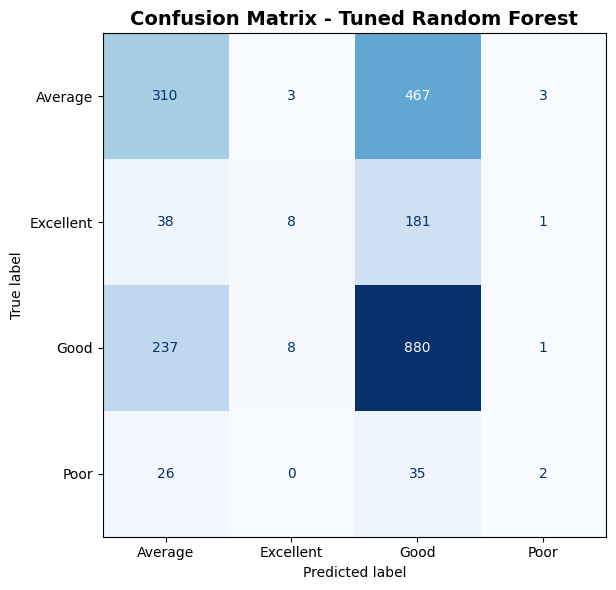

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - Tuned Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Feature Importance
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({
 'Feature': FEATURES,
 'Importance': importances
}).sort_values('Importance', ascending=False)

fig = px.bar(
 feat_imp_df, x='Feature', y='Importance',
 color='Importance', color_continuous_scale='Greens',
 title='Feature Importance - Random Forest',
 text='Importance'
)
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.show()

## 8. Save Models & Artifacts

In [27]:
joblib.dump(best_model, 'best_classification_model.pkl')
joblib.dump(scaler, 'classification_scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

## 9. Key Findings

**Best Model:** Tuned Random Forest

**Best Test Accuracy:** 0.5455

**Best F1 Score:** 0.5016

**Most Important Feature:** EnergyConsumption (0.348)

Class distribution in test set:
- Average: 783 samples
- Excellent: 228 samples
- Good: 1126 samples
- Poor: 63 samples